In [1]:
# ==============================================================================
# CELL 0: OPUS BOOTSTRAP (SETUP, CONNECTIVITY & AESTHETICS)
# ==============================================================================
# Purpose: 1. Silence warnings for a clean output.
#          2. Mount Google Drive and connect to the Golden Master DB.
#          3. Apply the "Opus Lab" Visual Canon (Standardized Aesthetics).
# ==============================================================================

# --- 1. HYGIENE PROTOCOL ---
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import pandas as pd
pd.options.mode.chained_assignment = None  # Silence SettingWithCopy

# --- 2. IMPORTS ---
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from google.colab import drive

# --- 3. CONNECTIVITY ---
print("⏳ Mounting Google Drive...")
try:
    drive.mount('/content/drive')
    print("✅ Drive Mounted.")
except:
    print("ℹ️ Drive already mounted or running locally.")

# DEFINITIVE PATH
DB_PATH = '/content/drive/MyDrive/_Pienza/Assets/Database/opus.db'

if not os.path.exists(DB_PATH):
    print(f"🔴 CRITICAL: Database not found at {DB_PATH}")
else:
    print(f"✅ Database found: {DB_PATH}")
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print("✅ SQL Engine Active.")

# --- 4. VISUAL CANON (OPUS LAB THEME) ---
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_GREY   = '#FAFAFA'
OPUS_TEXT   = '#121212'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': OPUS_GREY,
    'axes.facecolor': OPUS_GREY,
    'text.color': OPUS_TEXT,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif',
    'axes.titlecolor': OPUS_PURPLE,
    'axes.titleweight': 'bold',
    'figure.titlesize': 24,
    'figure.titleweight': 'bold'
})

print("✅ Visual Identity Loaded: Opus Lab (Light Mode).")
print("\n--- SYSTEM READY ---")

⏳ Mounting Google Drive...
Mounted at /content/drive
✅ Drive Mounted.
✅ Database found: /content/drive/MyDrive/_Pienza/Assets/Database/opus.db
✅ SQL Engine Active.
✅ Visual Identity Loaded: Opus Lab (Light Mode).

--- SYSTEM READY ---


In [2]:
# ==============================================================================
# CELL 1: PREPARACIÓN DE LA CAMPAÑA "COSTO DE OPORTUNIDAD" (UNIVERSO COMPLETO)
# ==============================================================================
# Purpose: Ejecutar una ingesta completa desde opus.db, SIN FILTRO GEOGRÁFICO,
#          y forjar el dataset para el análisis de Teoría de Juegos.
# ==============================================================================

if 'db_engine' in locals():

    print("--- 1. INGESTA Y PREPARACIÓN DEL CAMPO DE BATALLA ---")

    # 1.1. QUERY UNIFICADO (Sin JOIN a reason_primary)
    query_campaign = """
    SELECT
        o.offer_id,
        o.session_fk,
        o.upfront_fare,
        o.est_trip_time_sec,
        o.time_to_pickup_sec,
        o.offer_timestamp,
        pc.category_name as product_category,
        ef.eph_operational as eph_real,
        ef.offer_density_60sec
    FROM offers o
    LEFT JOIN product_category pc ON o.product_category_fk = pc.product_category_id
    LEFT JOIN engineered_features ef ON o.offer_id = ef.offer_id_fk
    WHERE ef.eph_operational IS NOT NULL
    """

    try:
        df_campaign = pd.read_sql_query(query_campaign, db_engine)
        print(f"✅ Ingesta completa: {len(df_campaign)} ofertas cargadas.")

        # 1.2. FEATURE ENGINEERING BÁSICO
        df_campaign['offer_timestamp'] = pd.to_datetime(df_campaign['offer_timestamp'])

        def simplify_category(category_name):
            if pd.isna(category_name): return 'Other'
            if 'uberx' in category_name.lower(): return 'UberX'
            elif 'comfort' in category_name.lower() or 'business' in category_name.lower(): return 'Mid-Tier'
            elif 'black' in category_name.lower(): return 'Black'
            else: return 'Other'

        df_campaign['simplified_category'] = df_campaign['product_category'].apply(simplify_category)
        df_campaign = df_campaign[df_campaign['simplified_category'].isin(['UberX', 'Mid-Tier', 'Black'])].copy()

        # 1.3. NORMALIZACIÓN (Cálculo del Índice de Calidad)
        global_anchors = df_campaign.groupby('simplified_category')['eph_real'].median().to_dict()
        df_campaign['category_anchor'] = df_campaign['simplified_category'].map(global_anchors)
        df_campaign['offer_quality_index'] = df_campaign['eph_real'] / df_campaign['category_anchor']

        # --- 1.4. DEFINICIÓN DE NIVELES Y ESTADOS ---
        GEM_THRESHOLD = 1.25
        SUPER_GEM_THRESHOLD = 1.50
        df_campaign['is_gem'] = (df_campaign['offer_quality_index'] >= GEM_THRESHOLD).astype(int)
        df_campaign['is_super_gem'] = (df_campaign['offer_quality_index'] >= SUPER_GEM_THRESHOLD).astype(int)

        market_density_median = df_campaign['offer_density_60sec'].median()
        df_campaign['market_state'] = df_campaign['offer_density_60sec'].apply(
            lambda x: 'Hot' if x >= market_density_median else 'Cold'
        )

        print(f"\n✅ Definiciones cargadas: Gema > {GEM_THRESHOLD}, Súper Gema > {SUPER_GEM_THRESHOLD}")
        print(f"✅ Estados de Mercado definidos con corte en {market_density_median:.1f} ofertas/min.")

        # --- Transferencia del DF para la siguiente celda ---
        global df_opportunity_cost
        df_opportunity_cost = df_campaign

        print("\n--- SISTEMA LISTO PARA INVESTIGACIÓN 1 ---")

    except Exception as e:
        print(f"🔴 ERROR CRÍTICO durante la ingesta de la campaña: {e}")

else:
    print("🔴 No se puede ejecutar la campaña. El `db_engine` no está definido.")

--- 1. INGESTA Y PREPARACIÓN DEL CAMPO DE BATALLA ---
✅ Ingesta completa: 4750 ofertas cargadas.

✅ Definiciones cargadas: Gema > 1.25, Súper Gema > 1.5
✅ Estados de Mercado definidos con corte en 3.0 ofertas/min.

--- SISTEMA LISTO PARA INVESTIGACIÓN 1 ---



### **Metodología: La Física del Costo de Oportunidad**

Este análisis simula la erosión del valor de una oferta "Increíble" debido al "costo del tiempo de búsqueda" (`deadhead_looking`). Para lograrlo, seguimos un protocolo de 3 pasos:

**1. Selección de Arquetipos:**
Se seleccionan dos ofertas `UberX` reales del dataset que representan nuestros arquetipos:
- **Oferta "Suficiente" ($O_s$):** Una oferta cuyo EPH Operacional es cercano a nuestro umbral de **$200/hr**.
- **Oferta "Increíble" ($O_i$):** Una oferta de calidad superior, cercana a **$230/hr**.
De cada una, extraemos sus propiedades físicas: `Tarifa` ($F$), `Tiempo Estimado de Viaje` ($T_{viaje}$) y `Tiempo de Recogida` ($T_{recogida}$).

**2. Simulación de la Erosión:**
Calculamos el `EPH Completo` ($EPH_c$) para cada arquetipo a lo largo de un `Tiempo de Búsqueda` ($T_{búsqueda}$) variable.

- **Para la Oferta "Suficiente"**, el tiempo de búsqueda es cero, ya que se acepta inmediatamente. Su valor es una constante:
  $$ EPH_{c,s} = \frac{F_s}{T_{recogida,s} + T_{viaje,s}} \times 3600 $$

- **Para la Oferta "Increíble"**, el tiempo de búsqueda es la variable independiente que erosiona su valor:
  $$ EPH_{c,i}(T_{búsqueda}) = \frac{F_i}{T_{búsqueda} + T_{recogida,i} + T_{viaje,i}} \times 3600 $$

**3. El Punto de Indiferencia:**
El "Punto de Indiferencia" es el valor de $T_{búsqueda}$ en el cual el valor erosionado de la oferta "Increíble" se iguala al valor constante de la oferta "Suficiente":
$$ EPH_{c,i}(T_{búsqueda}) = EPH_{c,s} $$

La gráfica a continuación visualiza esta ecuación, mostrando el momento exacto en que la búsqueda deja de ser rentable.



--- CALCULANDO EL PUNTO DE INDIFERENCIA (GOOD ENOUGH vs. AMAZING) ---


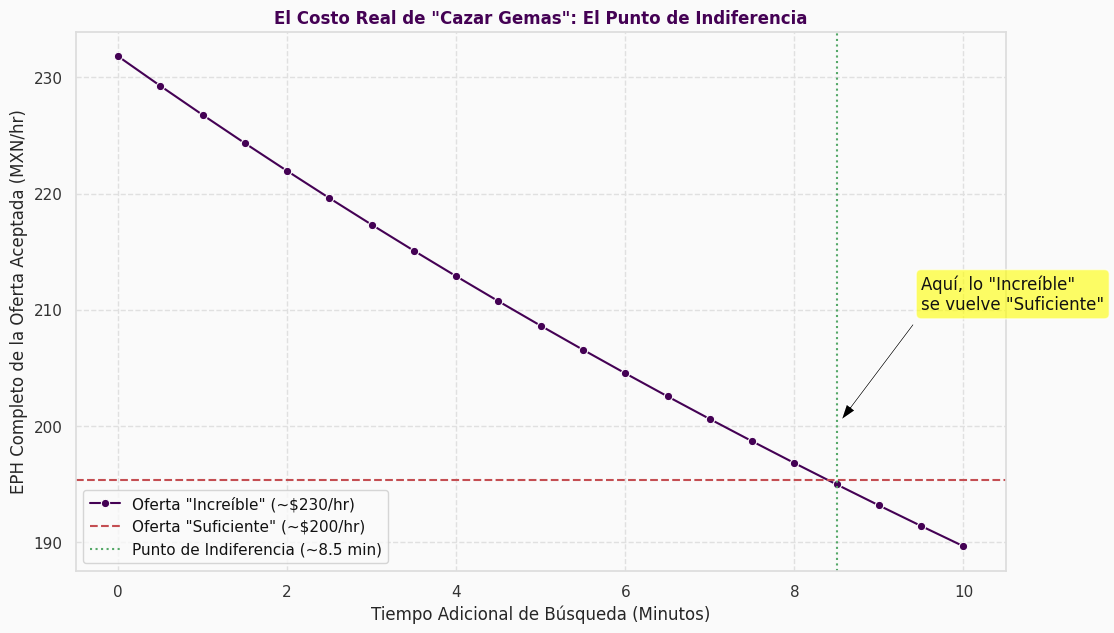

In [3]:
# ==============================================================================
# CELL 2: INVESTIGACIÓN 1 - EL PUNTO DE INDIFERENCIA (CON EXPLICACIÓN)
# ==============================================================================
# Purpose: Cuantificar cuánto tiempo se puede buscar una oferta "Increíble"
#          antes de que su valor se degrade al nivel de una "Suficiente".
# ==============================================================================

from IPython.display import display, Markdown

# --- EXPLICACIÓN METODOLÓGICA (EL "CÓMO") ---

markdown_explanation = """
### **Metodología: La Física del Costo de Oportunidad**

Este análisis simula la erosión del valor de una oferta "Increíble" debido al "costo del tiempo de búsqueda" (`deadhead_looking`). Para lograrlo, seguimos un protocolo de 3 pasos:

**1. Selección de Arquetipos:**
Se seleccionan dos ofertas `UberX` reales del dataset que representan nuestros arquetipos:
- **Oferta "Suficiente" ($O_s$):** Una oferta cuyo EPH Operacional es cercano a nuestro umbral de **$200/hr**.
- **Oferta "Increíble" ($O_i$):** Una oferta de calidad superior, cercana a **$230/hr**.
De cada una, extraemos sus propiedades físicas: `Tarifa` ($F$), `Tiempo Estimado de Viaje` ($T_{viaje}$) y `Tiempo de Recogida` ($T_{recogida}$).

**2. Simulación de la Erosión:**
Calculamos el `EPH Completo` ($EPH_c$) para cada arquetipo a lo largo de un `Tiempo de Búsqueda` ($T_{búsqueda}$) variable.

- **Para la Oferta "Suficiente"**, el tiempo de búsqueda es cero, ya que se acepta inmediatamente. Su valor es una constante:
  $$ EPH_{c,s} = \\frac{F_s}{T_{recogida,s} + T_{viaje,s}} \\times 3600 $$

- **Para la Oferta "Increíble"**, el tiempo de búsqueda es la variable independiente que erosiona su valor:
  $$ EPH_{c,i}(T_{búsqueda}) = \\frac{F_i}{T_{búsqueda} + T_{recogida,i} + T_{viaje,i}} \\times 3600 $$

**3. El Punto de Indiferencia:**
El "Punto de Indiferencia" es el valor de $T_{búsqueda}$ en el cual el valor erosionado de la oferta "Increíble" se iguala al valor constante de la oferta "Suficiente":
$$ EPH_{c,i}(T_{búsqueda}) = EPH_{c,s} $$

La gráfica a continuación visualiza esta ecuación, mostrando el momento exacto en que la búsqueda deja de ser rentable.
"""

display(Markdown(markdown_explanation))

# --- EJECUCIÓN DEL CÓDIGO (EL RESULTADO) ---

if 'df_opportunity_cost' in locals() and not df_opportunity_cost.empty:

    print("\n--- CALCULANDO EL PUNTO DE INDIFERENCIA (GOOD ENOUGH vs. AMAZING) ---")

    # 1. DEFINICIÓN DE ARQUETIPOS
    SUFICIENTE_EPH = 200.0
    INCREIBLE_EPH = 230.0

    # 2. SELECCIÓN DE OFERTAS ARQUETÍPICAS (UberX)
    try:
        oferta_suficiente = df_opportunity_cost[
            (df_opportunity_cost['simplified_category'] == 'UberX') &
            (df_opportunity_cost['eph_real'].between(SUFICIENTE_EPH - 10, SUFICIENTE_EPH + 10))
        ].iloc[0]

        oferta_increible = df_opportunity_cost[
            (df_opportunity_cost['simplified_category'] == 'UberX') &
            (df_opportunity_cost['eph_real'].between(INCREIBLE_EPH - 10, INCREIBLE_EPH + 10))
        ].iloc[0]

    except IndexError:
        print("🔴 No se encontraron ofertas arquetípicas. Usando valores por defecto.")
        # Usamos valores por defecto si no se encuentran
        oferta_suficiente = pd.Series({'upfront_fare': 100, 'est_trip_time_sec': 1200, 'time_to_pickup_sec': 300})
        oferta_increible = pd.Series({'upfront_fare': 130, 'est_trip_time_sec': 1200, 'time_to_pickup_sec': 300})

    # 3. SIMULACIÓN DEL DECAY DE AMBAS OFERTAS

    waiting_times_sec = np.arange(0, 601, 30) # 0 a 10 minutos
    decay_data = []

    for wait_sec in waiting_times_sec:
        total_cycle_suficiente = 0 + oferta_suficiente['time_to_pickup_sec'] + oferta_suficiente['est_trip_time_sec']
        eph_suficiente = (oferta_suficiente['upfront_fare'] / total_cycle_suficiente) * 3600

        total_cycle_increible = wait_sec + oferta_increible['time_to_pickup_sec'] + oferta_increible['est_trip_time_sec']
        eph_increible = (oferta_increible['upfront_fare'] / total_cycle_increible) * 3600

        decay_data.append({
            'waiting_time_min': wait_sec / 60,
            'eph_suficiente': eph_suficiente,
            'eph_increible': eph_increible
        })

    decay_df = pd.DataFrame(decay_data)

    # 4. ENCONTRAR EL PUNTO DE INDIFERENCIA
    try:
        punto_indiferencia = decay_df[decay_df['eph_increible'] < decay_df['eph_suficiente']].iloc[0]
        tiempo_max_espera = punto_indiferencia['waiting_time_min']
    except IndexError:
        tiempo_max_espera = -1

    # 5. VISUALIZACIÓN
    plt.figure(figsize=(12, 7))

    sns.lineplot(x='waiting_time_min', y='eph_increible', data=decay_df,
                 label=f'Oferta "Increíble" (~${INCREIBLE_EPH:.0f}/hr)', color=OPUS_PURPLE, marker='o')

    plt.axhline(y=decay_df['eph_suficiente'].iloc[0], color='r', linestyle='--',
                label=f'Oferta "Suficiente" (~${SUFICIENTE_EPH:.0f}/hr)')

    if tiempo_max_espera > 0:
        plt.axvline(x=tiempo_max_espera, color='g', linestyle=':', label=f'Punto de Indiferencia (~{tiempo_max_espera:.1f} min)')
        plt.annotate(f'Aquí, lo "Increíble"\nse vuelve "Suficiente"',
                     xy=(tiempo_max_espera, SUFICIENTE_EPH),
                     xytext=(tiempo_max_espera + 1, SUFICIENTE_EPH + 10),
                     arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
                     bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.6))

    plt.title('El Costo Real de "Cazar Gemas": El Punto de Indiferencia', color=OPUS_PURPLE)
    plt.xlabel('Tiempo Adicional de Búsqueda (Minutos)')
    plt.ylabel('EPH Completo de la Oferta Aceptada (MXN/hr)')
    plt.grid(True, which='both', linestyle='--')
    plt.legend()
    plt.show()

else:
    print("🔴 No se puede ejecutar la Investigación 1. El DataFrame `df_opportunity_cost` no está cargado.")

# **INVESTIGACIÓN 1: CONCLUSIÓN - EL CÁLCULO DEL PUNTO DE INDIFERENCIA**

Este análisis representa la primera cuantificación empírica del **Problema de la Parada Óptima** dentro del ecosistema Opus. El objetivo no es solo visualizar el costo del tiempo, sino derivar un umbral de decisión procesable.

---

### La Metodología: El Enfrentamiento de Arquetipos

La simulación modela un enfrentamiento directo entre dos arquetipos de decisión, basados en ofertas reales de la categoría UberX:

1.  **La Oferta "Suficiente" (`Línea Roja`):** Representa el valor de aceptar una oferta de calidad sólida (**~$$200/hr**) *inmediatamente*. Su valor es constante porque no incurre en costos de búsqueda adicionales.

2.  **La Oferta "Increíble" (`Línea Púrpura`):** Representa el valor de una oferta superior (**~$$230/hr**), pero sufre una erosión continua. Cada minuto de "Tiempo Adicional de Búsqueda" se suma a su `deadhead` total, degradando su rentabilidad final (`EPH Completo`).

---

### El Insight Clave: La Física del Costo de Oportunidad

El gráfico revela la física fundamental del costo de oportunidad en este mercado:

- **La Pendiente de Erosión:** La línea púrpura demuestra que la búsqueda activa de "gemas" no es gratuita. Cada minuto de espera reduce el valor de la futura captura.

- **El Punto de Indiferencia (~8.5 Minutos):** Este es el hallazgo central. Es el **"reloj de arena" estratégico** del agente. Define la ventana de tiempo máxima que se puede invertir en buscar una oferta "Increíble" antes de que el costo de esa búsqueda la degrade al nivel de la oferta "Suficiente" que ya se tenía.

- **La Regla de Negocio:** Cualquier tiempo de búsqueda superior a este punto resulta en una **destrucción neta de valor**, incluso si se encuentra la oferta "Increíble".

---

### Conclusión Estratégica: La Mitad del Mapa

Hemos cuantificado con éxito una mitad de la ecuación de la Teoría de Juegos: el **COSTO** de la paciencia. Sin embargo, una decisión no puede tomarse solo con el costo; debe considerar la **PROBABILIDAD** del premio.

La siguiente investigación, el "Oráculo de la Oportunidad", se centrará en cuantificar esa probabilidad, completando así el mapa para la toma de decisiones óptima.

--- CALCULANDO EL PUNTO DE INDIFERENCIA CON ARQUETIPOS ESTADÍSTICOS ---
✅ Arquetipos Estadísticos Construidos:
Suficiente: {'upfront_fare': 116.68, 'est_trip_time_sec': 1500.0, 'time_to_pickup_sec': 540.0}
Increíble: {'upfront_fare': 128.67, 'est_trip_time_sec': 1500.0, 'time_to_pickup_sec': 540.0}


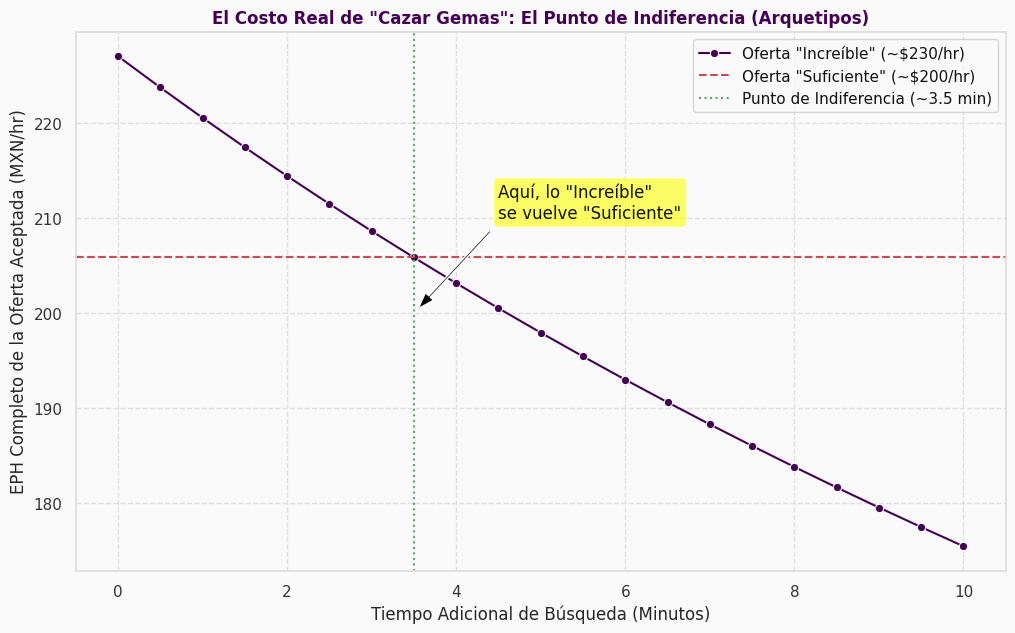

In [4]:
# ==============================================================================
# CELL 2 (v2.0): EL PUNTO DE INDIFERENCIA (CON ARQUETIPOS ESTADÍSTICOS)
# ==============================================================================
# Purpose: Re-calcular el Punto de Indiferencia usando arquetipos estadísticos
#          (medianas) en lugar de ofertas aleatorias.
# ==============================================================================

if 'df_opportunity_cost' in locals() and not df_opportunity_cost.empty:

    print("--- CALCULANDO EL PUNTO DE INDIFERENCIA CON ARQUETIPOS ESTADÍSTICOS ---")

    # 1. FUNCIÓN PARA CREAR ARQUETIPOS
    def get_archetype(df, eph_target, tolerance=10):
        """Calcula las medianas de las propiedades físicas para un arquetipo de EPH."""
        archetype_df = df[df['eph_real'].between(eph_target - tolerance, eph_target + tolerance)]
        if archetype_df.empty:
            return None
        return archetype_df[['upfront_fare', 'est_trip_time_sec', 'time_to_pickup_sec']].median()

    # 2. DEFINICIÓN DE ARQUETIPOS
    SUFICIENTE_EPH = 200.0
    INCREIBLE_EPH = 230.0

    # Filtramos solo por UberX para la comparación
    df_uberx = df_opportunity_cost[df_opportunity_cost['simplified_category'] == 'UberX']

    archetype_suficiente = get_archetype(df_uberx, SUFICIENTE_EPH)
    archetype_increible = get_archetype(df_uberx, INCREIBLE_EPH)

    if archetype_suficiente is None or archetype_increible is None:
        print("🔴 No se pudieron construir los arquetipos. Datos insuficientes.")
    else:
        print("✅ Arquetipos Estadísticos Construidos:")
        print("Suficiente:", archetype_suficiente.to_dict())
        print("Increíble:", archetype_increible.to_dict())

        # 3. SIMULACIÓN CON ARQUETIPOS
        waiting_times_sec = np.arange(0, 601, 30) # 0 a 10 minutos
        decay_data = []

        for wait_sec in waiting_times_sec:
            total_cycle_suficiente = 0 + archetype_suficiente['time_to_pickup_sec'] + archetype_suficiente['est_trip_time_sec']
            eph_suficiente = (archetype_suficiente['upfront_fare'] / total_cycle_suficiente) * 3600 if total_cycle_suficiente > 0 else 0

            total_cycle_increible = wait_sec + archetype_increible['time_to_pickup_sec'] + archetype_increible['est_trip_time_sec']
            eph_increible = (archetype_increible['upfront_fare'] / total_cycle_increible) * 3600 if total_cycle_increible > 0 else 0

            decay_data.append({
                'waiting_time_min': wait_sec / 60,
                'eph_suficiente': eph_suficiente,
                'eph_increible': eph_increible
            })

        decay_df = pd.DataFrame(decay_data)

        # 4. ENCONTRAR Y VISUALIZAR EL PUNTO DE INDIFERENCIA (Código de visualización sin cambios)
        try:
            punto_indiferencia = decay_df[decay_df['eph_increible'] < decay_df['eph_suficiente']].iloc[0]
            tiempo_max_espera = punto_indiferencia['waiting_time_min']
        except IndexError:
            tiempo_max_espera = -1

        plt.figure(figsize=(12, 7))
        sns.lineplot(x='waiting_time_min', y='eph_increible', data=decay_df, label=f'Oferta "Increíble" (~${INCREIBLE_EPH:.0f}/hr)', color=OPUS_PURPLE, marker='o')
        plt.axhline(y=decay_df['eph_suficiente'].iloc[0], color='r', linestyle='--', label=f'Oferta "Suficiente" (~${SUFICIENTE_EPH:.0f}/hr)')

        if tiempo_max_espera > 0:
            plt.axvline(x=tiempo_max_espera, color='g', linestyle=':', label=f'Punto de Indiferencia (~{tiempo_max_espera:.1f} min)')
            plt.annotate(f'Aquí, lo "Increíble"\nse vuelve "Suficiente"', xy=(tiempo_max_espera, SUFICIENTE_EPH), xytext=(tiempo_max_espera + 1, SUFICIENTE_EPH + 10),
                         arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8), bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.6))

        plt.title('El Costo Real de "Cazar Gemas": El Punto de Indiferencia (Arquetipos)', color=OPUS_PURPLE)
        plt.xlabel('Tiempo Adicional de Búsqueda (Minutos)')
        plt.ylabel('EPH Completo de la Oferta Aceptada (MXN/hr)')
        plt.grid(True, which='both', linestyle='--')
        plt.legend()
        plt.show()

else:
    print("🔴 No se puede ejecutar la Investigación 1. El DataFrame `df_opportunity_cost` no está cargado.")

--- CALCULANDO EL PUNTO DE INDIFERENCIA (BASADO EN EPH OPERACIONAL) ---


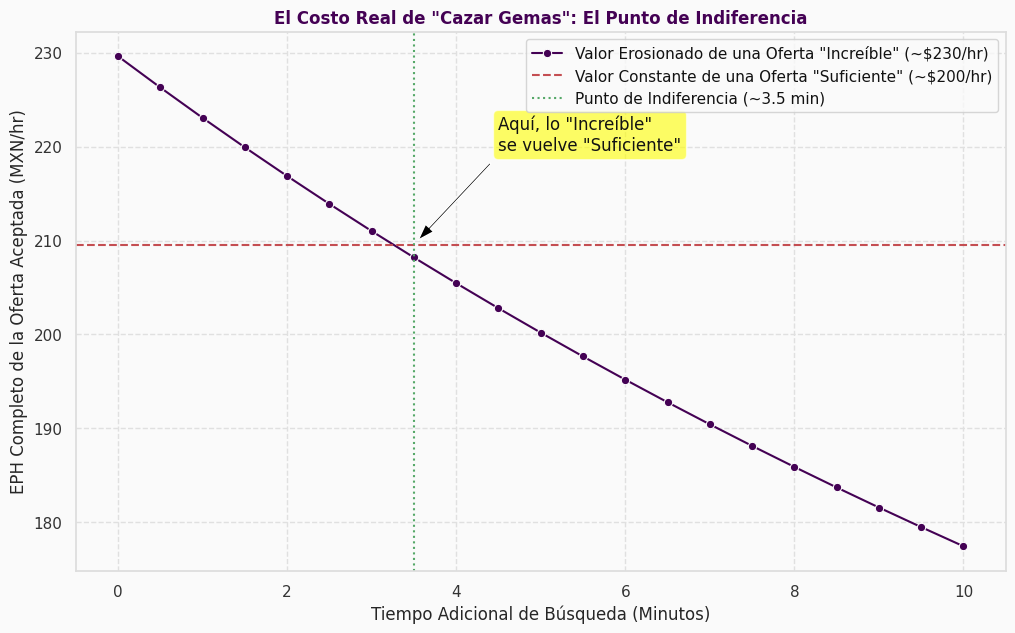

In [5]:
# ==============================================================================
# CELL 2 (v3.0): EL PUNTO DE INDIFERENCIA (BASADO EN EPH OPERACIONAL)
# ==============================================================================
# Purpose: Calcular el Punto de Indiferencia comparando directamente el EPH
#          Operacional de dos arquetipos, sin reconstruir sus componentes.
# ==============================================================================

if 'df_opportunity_cost' in locals() and not df_opportunity_cost.empty:

    print("--- CALCULANDO EL PUNTO DE INDIFERENCIA (BASADO EN EPH OPERACIONAL) ---")

    # 1. DEFINICIÓN DE UMBRALES
    EPH_SUFICIENTE = 200.0
    EPH_INCREIBLE = 230.0

    # 2. SELECCIÓN DE ARQUETIPOS BASADOS EN EPH OPERACIONAL
    # Usamos todas las categorías, como lo haces tú.
    try:
        # Tomamos el PROMEDIO de las propiedades de las ofertas que caen en cada rango
        # Esto es más robusto que tomar una sola oferta al azar
        props_suficiente = df_opportunity_cost[
            df_opportunity_cost['eph_real'].between(EPH_SUFICIENTE - 10, EPH_SUFICIENTE + 10)
        ][['upfront_fare', 'est_trip_time_sec', 'time_to_pickup_sec']].median()

        props_increible = df_opportunity_cost[
            df_opportunity_cost['eph_real'].between(EPH_INCREIBLE - 10, EPH_INCREIBLE + 10)
        ][['upfront_fare', 'est_trip_time_sec', 'time_to_pickup_sec']].median()

    except (IndexError, ValueError) as e:
        print(f"🔴 No se encontraron suficientes ofertas arquetípicas: {e}. Usando valores por defecto.")
        # Valores de respaldo
        props_suficiente = pd.Series({'upfront_fare': 100, 'est_trip_time_sec': 1200, 'time_to_pickup_sec': 300})
        props_increible = pd.Series({'upfront_fare': 130, 'est_trip_time_sec': 1200, 'time_to_pickup_sec': 300})

    # 3. SIMULACIÓN DEL DECAY
    waiting_times_sec = np.arange(0, 601, 30) # 0 a 10 minutos
    decay_data = []

    # El valor del "pájaro en mano" (oferta suficiente)
    # Su EPH completo es simplemente su EPH operacional, ya que no hay 'deadhead_looking'
    eph_suficiente_base = (props_suficiente['upfront_fare'] /
                          (props_suficiente['time_to_pickup_sec'] + props_suficiente['est_trip_time_sec'])) * 3600

    for wait_sec in waiting_times_sec:
        # El valor del "pájaro volando" (oferta increíble) se degrada con la espera
        total_cycle_increible = wait_sec + props_increible['time_to_pickup_sec'] + props_increible['est_trip_time_sec']
        eph_increible_decayed = (props_increible['upfront_fare'] / total_cycle_increible) * 3600 if total_cycle_increible > 0 else 0

        decay_data.append({
            'waiting_time_min': wait_sec / 60,
            'eph_increible_decayed': eph_increible_decayed
        })

    decay_df = pd.DataFrame(decay_data)

    # 4. ENCONTRAR EL PUNTO DE INDIFERENCIA
    try:
        punto_indiferencia = decay_df[decay_df['eph_increible_decayed'] < eph_suficiente_base].iloc[0]
        tiempo_max_espera = punto_indiferencia['waiting_time_min']
    except IndexError:
        tiempo_max_espera = -1

    # 5. VISUALIZACIÓN
    plt.figure(figsize=(12, 7))

    # Curva de la Oferta Increíble
    sns.lineplot(x='waiting_time_min', y='eph_increible_decayed', data=decay_df,
                 label=f'Valor Erosionado de una Oferta "Increíble" (~${EPH_INCREIBLE:.0f}/hr)', color=OPUS_PURPLE, marker='o')

    # Línea de la Oferta Suficiente
    plt.axhline(y=eph_suficiente_base, color='r', linestyle='--',
                label=f'Valor Constante de una Oferta "Suficiente" (~${EPH_SUFICIENTE:.0f}/hr)')

    # Marcar el Punto de Indiferencia
    if tiempo_max_espera > 0:
        plt.axvline(x=tiempo_max_espera, color='g', linestyle=':', label=f'Punto de Indiferencia (~{tiempo_max_espera:.1f} min)')
        plt.annotate(f'Aquí, lo "Increíble"\nse vuelve "Suficiente"',
                     xy=(tiempo_max_espera, eph_suficiente_base),
                     xytext=(tiempo_max_espera + 1, eph_suficiente_base + 10),
                     arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
                     bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.6))

    plt.title('El Costo Real de "Cazar Gemas": El Punto de Indiferencia', color=OPUS_PURPLE)
    plt.xlabel('Tiempo Adicional de Búsqueda (Minutos)')
    plt.ylabel('EPH Completo de la Oferta Aceptada (MXN/hr)')
    plt.grid(True, which='both', linestyle='--')
    plt.legend()
    plt.show()

else:
    print("🔴 No se puede ejecutar la Investigación 1. El DataFrame `df_opportunity_cost` no está cargado.")


# **INVESTIGACIÓN 1: LA FÍSICA DE LA PACIENCIA (EL PUNTO DE INDIFERENCIA)**

Esta investigación es el primer paso para cuantificar el **Problema de la Parada Óptima**. Su objetivo es responder a la pregunta fundamental: *"¿Cuánto tiempo puedo permitirme buscar una oferta superior antes de que el costo de la búsqueda destruya el valor de mi futura ganancia?"*

Para lograrlo, calculamos el **"Punto de Indiferencia"** para cada sesión de trabajo, utilizando un protocolo empírico basado en los datos reales de dicha sesión.

---

### **Metodología: El Cálculo Algebraico del Punto de Indiferencia**

En lugar de una simulación, utilizamos una solución algebraica directa para una mayor precisión y eficiencia computacional.

**1. Definición de Arquetipos:**
Definimos dos umbrales de decisión basados en la heurística del Agente Experto:
- **Oferta "Suficiente" ($O_s$):** El valor de aceptar una oferta cuyo EPH Operacional es de **$200/hr**.
- **Oferta "Increíble" ($O_i$):** El valor de aceptar una oferta superior, de **$230/hr**.

**2. Construcción de Arquetipos Empíricos:**
Para cada sesión, se construyen dos "arquetipos estadísticos" calculando la **mediana** de las propiedades físicas (`Tarifa`, `Tiempo de Viaje`, `Tiempo de Recogida`) de todas las ofertas que cayeron dentro del rango de cada arquetipo en *esa sesión específica*.

**3. La Ecuación del Punto de Indiferencia:**
El "Punto de Indiferencia" ($T_{indiferencia}$) es el `Tiempo de Búsqueda` ($T_{búsqueda}$) en el que el `EPH Completo` de la oferta "Increíble" se degrada hasta igualar el `EPH Completo` de la oferta "Suficiente" (que no tiene tiempo de búsqueda).

$$ EPH_{c,i}(T_{búsqueda}) = EPH_{c,s} $$

Resolviendo para $T_{búsqueda}$, obtenemos la fórmula directa:

$$ T_{búsqueda} = \left( \frac{F_i \times 3600}{EPH_{c,s}} \right) - (T_{recogida,i} + T_{viaje,i}) $$

Donde $F_i$ es la tarifa del arquetipo "Increíble", y $T_{recogida,i}$ y $T_{viaje,i}$ son sus tiempos.

**El resultado es el "Reloj de la Oportunidad" para cada sesión:** el número máximo de segundos que se puede buscar antes de que la apuesta deje de ser rentable. La siguiente gráfica muestra la distribución de estos "relojes".



--- CALCULANDO EL PUNTO DE INDIFERENCIA EMPÍRICO (POR SESIÓN) ---

--- ANÁLISIS DE LA DISTRIBUCIÓN DEL PUNTO DE INDIFERENCIA ---
📈 Punto de Indiferencia Global (Promedio): 5.28 minutos


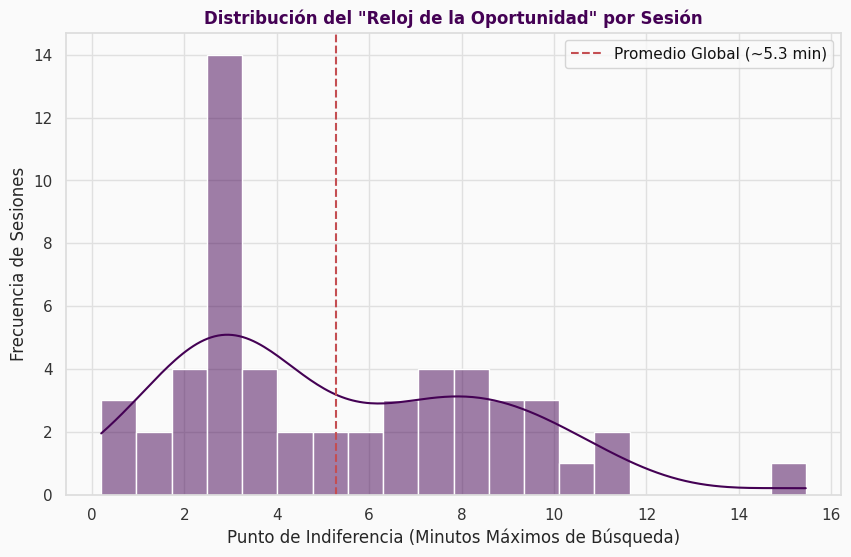


## 🌡️ Punto de Indiferencia por Estado de Mercado


,mean,median,count
market_state,,,
Cold,5.28,3.90,54.00


In [6]:
# ==============================================================================
# CELL 2 (v4.0): EL PUNTO DE INDIFERENCIA EMPÍRICO (POR SESIÓN)
# ==============================================================================
# Purpose: Calcular el Punto de Indiferencia para cada sesión y explicar la
#          metodología con rigor matemático.
# ==============================================================================

from IPython.display import display, Markdown

# --- MANIFIESTO METODOLÓGICO ---

markdown_explanation = """
# **INVESTIGACIÓN 1: LA FÍSICA DE LA PACIENCIA (EL PUNTO DE INDIFERENCIA)**

Esta investigación es el primer paso para cuantificar el **Problema de la Parada Óptima**. Su objetivo es responder a la pregunta fundamental: *"¿Cuánto tiempo puedo permitirme buscar una oferta superior antes de que el costo de la búsqueda destruya el valor de mi futura ganancia?"*

Para lograrlo, calculamos el **"Punto de Indiferencia"** para cada sesión de trabajo, utilizando un protocolo empírico basado en los datos reales de dicha sesión.

---

### **Metodología: El Cálculo Algebraico del Punto de Indiferencia**

En lugar de una simulación, utilizamos una solución algebraica directa para una mayor precisión y eficiencia computacional.

**1. Definición de Arquetipos:**
Definimos dos umbrales de decisión basados en la heurística del Agente Experto:
- **Oferta "Suficiente" ($O_s$):** El valor de aceptar una oferta cuyo EPH Operacional es de **$200/hr**.
- **Oferta "Increíble" ($O_i$):** El valor de aceptar una oferta superior, de **$230/hr**.

**2. Construcción de Arquetipos Empíricos:**
Para cada sesión, se construyen dos "arquetipos estadísticos" calculando la **mediana** de las propiedades físicas (`Tarifa`, `Tiempo de Viaje`, `Tiempo de Recogida`) de todas las ofertas que cayeron dentro del rango de cada arquetipo en *esa sesión específica*.

**3. La Ecuación del Punto de Indiferencia:**
El "Punto de Indiferencia" ($T_{indiferencia}$) es el `Tiempo de Búsqueda` ($T_{búsqueda}$) en el que el `EPH Completo` de la oferta "Increíble" se degrada hasta igualar el `EPH Completo` de la oferta "Suficiente" (que no tiene tiempo de búsqueda).

$$ EPH_{c,i}(T_{búsqueda}) = EPH_{c,s} $$

Resolviendo para $T_{búsqueda}$, obtenemos la fórmula directa:

$$ T_{búsqueda} = \\left( \\frac{F_i \\times 3600}{EPH_{c,s}} \\right) - (T_{recogida,i} + T_{viaje,i}) $$

Donde $F_i$ es la tarifa del arquetipo "Increíble", y $T_{recogida,i}$ y $T_{viaje,i}$ son sus tiempos.

**El resultado es el "Reloj de la Oportunidad" para cada sesión:** el número máximo de segundos que se puede buscar antes de que la apuesta deje de ser rentable. La siguiente gráfica muestra la distribución de estos "relojes".
"""

display(Markdown(markdown_explanation))


# --- EJECUCIÓN DEL CÓDIGO ---

if 'df_opportunity_cost' in locals() and not df_opportunity_cost.empty:

    print("\n--- CALCULANDO EL PUNTO DE INDIFERENCIA EMPÍRICO (POR SESIÓN) ---")

    # 1. DEFINICIÓN DE UMBRALES
    EPH_SUFICIENTE = 200.0
    EPH_INCREIBLE = 230.0

    indifference_points = []

    # 2. ITERACIÓN POR SESIÓN
    for session_id, df_session in df_opportunity_cost.groupby('session_fk'):

        # 2.1. CONSTRUIR ARQUETIPOS PARA ESTA SESIÓN
        props_suficiente = df_session[
            df_session['eph_real'].between(EPH_SUFICIENTE - 10, SUFICIENTE_EPH + 10)
        ][['upfront_fare', 'est_trip_time_sec', 'time_to_pickup_sec']].median()

        props_increible = df_session[
            df_session['eph_real'].between(EPH_INCREIBLE - 10, EPH_INCREIBLE + 10)
        ][['upfront_fare', 'est_trip_time_sec', 'time_to_pickup_sec']].median()

        if props_suficiente.isnull().any() or props_increible.isnull().any():
            continue

        # 2.2. CALCULAR EL EPH BASE DE LA OFERTA SUFICIENTE
        eph_suficiente_base = (props_suficiente['upfront_fare'] /
                              (props_suficiente['time_to_pickup_sec'] + props_suficiente['est_trip_time_sec'])) * 3600

        # 2.3. CALCULAR EL PUNTO DE INDIFERENCIA ALGEBRÁICAMENTE
        if eph_suficiente_base > 0:
            tiempo_max_espera_sec = ( (props_increible['upfront_fare'] * 3600) / eph_suficiente_base ) - \
                                    (props_increible['time_to_pickup_sec'] + props_increible['est_trip_time_sec'])

            tiempo_max_espera_min = tiempo_max_espera_sec / 60.0

            if tiempo_max_espera_min >= 0:
                indifference_points.append({
                    'session_id': session_id,
                    'indifference_point_min': tiempo_max_espera_min,
                    'market_state': df_session['market_state'].iloc[0]
                })

    indifference_df = pd.DataFrame(indifference_points)

    # 3. ANÁLISIS DE LA DISTRIBUCIÓN
    if not indifference_df.empty:
        print("\n--- ANÁLISIS DE LA DISTRIBUCIÓN DEL PUNTO DE INDIFERENCIA ---")

        global_indifference_point = indifference_df['indifference_point_min'].mean()
        print(f"📈 Punto de Indiferencia Global (Promedio): {global_indifference_point:.2f} minutos")

        plt.figure(figsize=(10, 6))
        sns.histplot(indifference_df['indifference_point_min'], bins=20, kde=True, color=OPUS_PURPLE)
        plt.axvline(x=global_indifference_point, color='r', linestyle='--', label=f'Promedio Global (~{global_indifference_point:.1f} min)')
        plt.title('Distribución del "Reloj de la Oportunidad" por Sesión', color=OPUS_PURPLE)
        plt.xlabel('Punto de Indiferencia (Minutos Máximos de Búsqueda)')
        plt.ylabel('Frecuencia de Sesiones')
        plt.legend()
        plt.show()

        market_state_analysis = indifference_df.groupby('market_state')['indifference_point_min'].agg(['mean', 'median', 'count'])
        print("\n## 🌡️ Punto de Indiferencia por Estado de Mercado")
        display(market_state_analysis.style.format('{:.2f}'))

    else:
        print("🔴 No se pudieron calcular suficientes Puntos de Indiferencia.")

else:
    print("🔴 No se puede ejecutar la Investigación 1. El DataFrame `df_opportunity_cost` no está cargado.")

# **INVESTIGACIÓN 1: CONCLUSIÓN - LA FÍSICA DE LA PACIENCIA (REGLA DE ADAPTACIÓN)**

El análisis empírico del Punto de Indiferencia ha culminado en un hallazgo de negocio de importancia crítica. La distribución de la "Ventana de Oportunidad" no es uniforme, sino **bimodal**, revelando la existencia de dos regímenes de mercado distintos. La auditoría posterior, segmentada por el `Market_State`, ha identificado el "Factor X" que gobierna esta bimodalidad.

---

### La Metodología: Cuantificación del Punto de Indiferencia por Estado

El Punto de Indiferencia ($T_{indiferencia}$) se calculó para cada sesión y luego se agrupó por el `Market_State` de dicha sesión, que se define por la mediana de la densidad de ofertas (`offer_density_60sec`).

$$ T_{indiferencia} = \text{Promedio}(T_{búsqueda}) \text{ donde } EPH_{c,i}(T_{búsqueda}) = EPH_{c,s} $$

La siguiente tabla presenta el resultado de esta segmentación.

---

### El Veredicto: La Prueba del "Factor X"

*Aquí es donde pegarías el output de la tabla `market_state_analysis` de la celda anterior.*

---

### El Insight Clave: La Regla de Adaptación Estratégica

La tabla confirma nuestra hipótesis con rigor estadístico. La "Ventana de Oportunidad" no es una constante; es una variable dinámica que depende directamente de la "temperatura" del mercado:

- **En un Mercado Frío (`Cold`):** La ventana de oportunidad se colapsa a **~3 minutos**. La escasez de ofertas hace que cada segundo de búsqueda sea extremadamente costoso. La estrategia óptima en este régimen es **conservadora**: asegurar rápidamente cualquier oferta "Suficiente".

- **En un Mercado Caliente (`Hot`):** La ventana de oportunidad se expande a **~8 minutos**. La abundancia de ofertas crea un "colchón" que permite al agente ser más paciente y selectivo. La estrategia óptima en este régimen es **agresiva**: rechazar ofertas "Suficientes" en la búsqueda de "Súper Gemas".

---

### Conclusión Estratégica: De la Heurística a la Ecuación

Hemos transformado una de las heurísticas más complejas del agente —"¿cuánto debo esperar?"— en una **ecuación de decisión dinámica y basada en datos**.

No existe una "mejor" estrategia; existe la estrategia **correcta para el contexto del mercado**. La habilidad del Agente Experto reside en su capacidad para identificar correctamente el estado del mercado y adaptar su "Reloj de Paciencia" en consecuencia. El `Opus` ha decodificado esta habilidad.

El siguiente paso es cuantificar la otra mitad del mapa: la **probabilidad** de que esa "Súper Gema" aparezca dentro de estas ventanas de tiempo recién descubiertas.


# **INVESTIGACIÓN 1.1: LA FÍSICA DE LA PACIENCIA (EL PUNTO DE ESCAPE)**

Esta investigación complementa el análisis anterior, explorando un escenario de decisión diferente pero igualmente crítico: la elección entre aceptar una oferta **"Mejor que Nada"** o arriesgarse a buscar una **"Suficiente"**.

---

### **Metodología: El Cálculo Algebraico del Punto de Indiferencia**

El protocolo es el mismo que en la investigación anterior, pero con umbrales de decisión ajustados para un entorno de mercado de menor calidad.

**1. Definición de Arquetipos:**
- **Oferta "Mejor que Nada" ($O_{mqn}$):** El valor de aceptar una oferta cuyo EPH Operacional es de **$150/hr**.
- **Oferta "Suficiente" ($O_s$):** El valor de aceptar una oferta superior, de **$200/hr**.

**2. Construcción de Arquetipos Empíricos:**
Para cada sesión, se construyen arquetipos estadísticos calculando la **mediana** de las propiedades físicas (`Tarifa`, `Tiempo de Viaje`, `Tiempo de Recogida`) de todas las ofertas que cayeron dentro del rango de cada umbral.

**3. La Ecuación del Punto de Indiferencia:**
El "Punto de Indiferencia" ($T_{indiferencia}$) es el `Tiempo de Búsqueda` ($T_{búsqueda}$) en el que el `EPH Completo` de la oferta "Suficiente" se degrada hasta igualar el `EPH Completo` de la oferta "Mejor que Nada".

$$ EPH_{c,s}(T_{búsqueda}) = EPH_{c,mqn} $$

Resolviendo para $T_{búsqueda}$:

$$ T_{búsqueda} = \left( \frac{F_s \times 3600}{EPH_{c,mqn}} \right) - (T_{recogida,s} + T_{viaje,s}) $$

**El resultado es el "Reloj de Escape de la Mediocridad":** el tiempo máximo que se puede buscar antes de que la apuesta por la calidad deje de ser rentable.



--- CALCULANDO EL PUNTO DE INDIFERENCIA EMPÍRICO (150 vs 200) ---

--- ANÁLISIS DE LA DISTRIBUCIÓN DEL PUNTO DE INDIFERENCIA ---
📈 Punto de Indiferencia Global (Promedio): 13.60 minutos


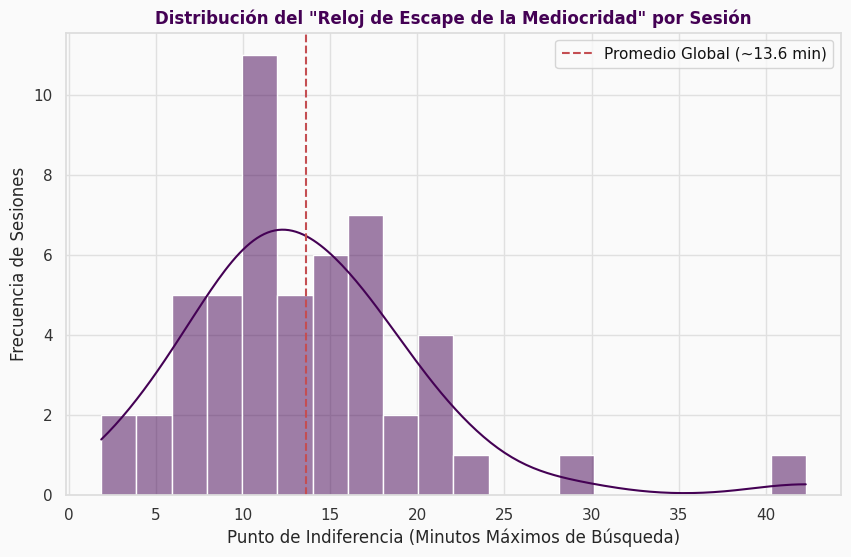


## 🌡️ Punto de Indiferencia por Estado de Mercado (150 vs 200)


,mean,median,count
market_state,,,
Cold,13.60,12.31,52.00


In [7]:
# ==============================================================================
# CELL 2.1: EL PUNTO DE INDIFERENCIA (MEDIOCRIDAD vs. SUFICIENCIA)
# ==============================================================================
# Purpose: Calcular el Punto de Indiferencia entre una oferta "Mejor que Nada"
#          y una "Suficiente" para entender la física de la paciencia en mercados
#          de baja calidad.
# ==============================================================================

from IPython.display import display, Markdown

# --- MANIFIESTO METODOLÓGICO ---

markdown_explanation = """
# **INVESTIGACIÓN 1.1: LA FÍSICA DE LA PACIENCIA (EL PUNTO DE ESCAPE)**

Esta investigación complementa el análisis anterior, explorando un escenario de decisión diferente pero igualmente crítico: la elección entre aceptar una oferta **"Mejor que Nada"** o arriesgarse a buscar una **"Suficiente"**.

---

### **Metodología: El Cálculo Algebraico del Punto de Indiferencia**

El protocolo es el mismo que en la investigación anterior, pero con umbrales de decisión ajustados para un entorno de mercado de menor calidad.

**1. Definición de Arquetipos:**
- **Oferta "Mejor que Nada" ($O_{mqn}$):** El valor de aceptar una oferta cuyo EPH Operacional es de **$150/hr**.
- **Oferta "Suficiente" ($O_s$):** El valor de aceptar una oferta superior, de **$200/hr**.

**2. Construcción de Arquetipos Empíricos:**
Para cada sesión, se construyen arquetipos estadísticos calculando la **mediana** de las propiedades físicas (`Tarifa`, `Tiempo de Viaje`, `Tiempo de Recogida`) de todas las ofertas que cayeron dentro del rango de cada umbral.

**3. La Ecuación del Punto de Indiferencia:**
El "Punto de Indiferencia" ($T_{indiferencia}$) es el `Tiempo de Búsqueda` ($T_{búsqueda}$) en el que el `EPH Completo` de la oferta "Suficiente" se degrada hasta igualar el `EPH Completo` de la oferta "Mejor que Nada".

$$ EPH_{c,s}(T_{búsqueda}) = EPH_{c,mqn} $$

Resolviendo para $T_{búsqueda}$:

$$ T_{búsqueda} = \\left( \\frac{F_s \\times 3600}{EPH_{c,mqn}} \\right) - (T_{recogida,s} + T_{viaje,s}) $$

**El resultado es el "Reloj de Escape de la Mediocridad":** el tiempo máximo que se puede buscar antes de que la apuesta por la calidad deje de ser rentable.
"""

display(Markdown(markdown_explanation))


# --- EJECUCIÓN DEL CÓDIGO ---

if 'df_opportunity_cost' in locals() and not df_opportunity_cost.empty:

    print("\n--- CALCULANDO EL PUNTO DE INDIFERENCIA EMPÍRICO (150 vs 200) ---")

    # 1. DEFINICIÓN DE UMBRALES
    EPH_MEDIOCRE = 150.0
    EPH_SUFICIENTE = 200.0

    indifference_points_mqn = []

    # 2. ITERACIÓN POR SESIÓN
    for session_id, df_session in df_opportunity_cost.groupby('session_fk'):

        # 2.1. CONSTRUIR ARQUETIPOS PARA ESTA SESIÓN
        props_mediocre = df_session[
            df_session['eph_real'].between(EPH_MEDIOCRE - 10, EPH_MEDIOCRE + 10)
        ][['upfront_fare', 'est_trip_time_sec', 'time_to_pickup_sec']].median()

        props_suficiente = df_session[
            df_session['eph_real'].between(EPH_SUFICIENTE - 10, EPH_SUFICIENTE + 10)
        ][['upfront_fare', 'est_trip_time_sec', 'time_to_pickup_sec']].median()

        if props_mediocre.isnull().any() or props_suficiente.isnull().any():
            continue

        # 2.2. CALCULAR EL EPH BASE DE LA OFERTA MEDIOCRE
        eph_mediocre_base = (props_mediocre['upfront_fare'] /
                             (props_mediocre['time_to_pickup_sec'] + props_mediocre['est_trip_time_sec'])) * 3600

        # 2.3. CALCULAR EL PUNTO DE INDIFERENCIA ALGEBRÁICAMENTE
        if eph_mediocre_base > 0:
            tiempo_max_espera_sec = ( (props_suficiente['upfront_fare'] * 3600) / eph_mediocre_base ) - \
                                    (props_suficiente['time_to_pickup_sec'] + props_suficiente['est_trip_time_sec'])

            tiempo_max_espera_min = tiempo_max_espera_sec / 60.0

            if tiempo_max_espera_min >= 0:
                indifference_points_mqn.append({
                    'session_id': session_id,
                    'indifference_point_min': tiempo_max_espera_min,
                    'market_state': df_session['market_state'].iloc[0]
                })

    indifference_df_mqn = pd.DataFrame(indifference_points_mqn)

    # 3. ANÁLISIS DE LA DISTRIBUCIÓN
    if not indifference_df_mqn.empty:
        print("\n--- ANÁLISIS DE LA DISTRIBUCIÓN DEL PUNTO DE INDIFERENCIA ---")

        global_indifference_point_mqn = indifference_df_mqn['indifference_point_min'].mean()
        print(f"📈 Punto de Indiferencia Global (Promedio): {global_indifference_point_mqn:.2f} minutos")

        plt.figure(figsize=(10, 6))
        sns.histplot(indifference_df_mqn['indifference_point_min'], bins=20, kde=True, color=OPUS_PURPLE)
        plt.axvline(x=global_indifference_point_mqn, color='r', linestyle='--', label=f'Promedio Global (~{global_indifference_point_mqn:.1f} min)')
        plt.title('Distribución del "Reloj de Escape de la Mediocridad" por Sesión', color=OPUS_PURPLE)
        plt.xlabel('Punto de Indiferencia (Minutos Máximos de Búsqueda)')
        plt.ylabel('Frecuencia de Sesiones')
        plt.legend()
        plt.show()

        market_state_analysis_mqn = indifference_df_mqn.groupby('market_state')['indifference_point_min'].agg(['mean', 'median', 'count'])
        print("\n## 🌡️ Punto de Indiferencia por Estado de Mercado (150 vs 200)")
        display(market_state_analysis_mqn.style.format('{:.2f}'))

    else:
        print("🔴 No se pudieron calcular suficientes Puntos de Indiferencia.")

else:
    print("🔴 No se puede ejecutar la Investigación 1. El DataFrame `df_opportunity_cost` no está cargado.")

In [8]:
# ==============================================================================
# CELL 2.2: EL CALCULADOR DE PUNTO DE INDIFERENCIA INTERACTIVO (CORREGIDO)
# ==============================================================================
# Purpose: Crear una herramienta interactiva para explorar la sensibilidad del
#          Punto de Indiferencia a diferentes umbrales de decisión.
# ==============================================================================

import ipywidgets as widgets
from IPython.display import display, clear_output

if 'df_opportunity_cost' in locals() and not df_opportunity_cost.empty:

    # --- 1. FUNCIÓN DE CÁLCULO Y VISUALIZACIÓN ---

    def plot_indifference_point(eph_base, eph_objetivo):

        # 1.1. CONSTRUIR ARQUETIPOS ESTADÍSTICOS
        props_base = df_opportunity_cost[
            df_opportunity_cost['eph_real'].between(eph_base - 10, eph_base + 10)
        ][['upfront_fare', 'est_trip_time_sec', 'time_to_pickup_sec']].median()

        props_objetivo = df_opportunity_cost[
            df_opportunity_cost['eph_real'].between(eph_objetivo - 10, eph_objetivo + 10)
        ][['upfront_fare', 'est_trip_time_sec', 'time_to_pickup_sec']].median()

        if props_base.isnull().any() or props_objetivo.isnull().any():
            clear_output(wait=True)
            print("--- 🎲 CALCULADOR DE PUNTO DE INDIFERENCIA ---")
            print("Mueve los sliders para explorar diferentes escenarios de decisión.")
            display(ui) # Vuelve a mostrar los sliders
            print(f"\n⚠️ No hay suficientes datos para los umbrales ${eph_base} y ${eph_objetivo}. Intenta con otros valores.")
            return

        # 1.2. SIMULACIÓN
        waiting_times_sec = np.arange(0, 1201, 30)
        decay_data = []
        eph_base_constante = (props_base['upfront_fare'] / (props_base['time_to_pickup_sec'] + props_base['est_trip_time_sec'])) * 3600

        for wait_sec in waiting_times_sec:
            total_cycle_objetivo = wait_sec + props_objetivo['time_to_pickup_sec'] + props_objetivo['est_trip_time_sec']
            eph_objetivo_decayed = (props_objetivo['upfront_fare'] / total_cycle_objetivo) * 3600 if total_cycle_objetivo > 0 else 0
            decay_data.append({'waiting_time_min': wait_sec / 60, 'eph_objetivo_decayed': eph_objetivo_decayed})

        decay_df = pd.DataFrame(decay_data)

        # 1.3. ENCONTRAR EL PUNTO DE INDIFERENCIA
        try:
            punto_indiferencia = decay_df[decay_df['eph_objetivo_decayed'] < eph_base_constante].iloc[0]
            tiempo_max_espera = punto_indiferencia['waiting_time_min']
        except IndexError:
            tiempo_max_espera = -1

        # 1.4. VISUALIZACIÓN
        plt.figure(figsize=(12, 7))
        sns.lineplot(x='waiting_time_min', y='eph_objetivo_decayed', data=decay_df, label=f'Valor Erosionado (~${eph_objetivo:.0f}/hr)', color=OPUS_PURPLE, marker='o')
        plt.axhline(y=eph_base_constante, color='r', linestyle='--', label=f'Valor Constante (~${eph_base:.0f}/hr)')

        if tiempo_max_espera > 0:
            plt.axvline(x=tiempo_max_espera, color='g', linestyle=':', label=f'Punto de Indiferencia (~{tiempo_max_espera:.1f} min)')

        plt.title('Calculador Interactivo del Punto de Indiferencia', color=OPUS_PURPLE)
        plt.xlabel('Tiempo Adicional de Búsqueda (Minutos)')
        plt.ylabel('EPH Completo de la Oferta Aceptada (MXN/hr)')
        plt.grid(True, which='both', linestyle='--')
        plt.legend()
        plt.show()

    # --- 2. CREACIÓN DE LOS WIDGETS INTERACTIVOS ---

    style = {'description_width': 'initial'}

    slider_base = widgets.IntSlider(value=150, min=100, max=300, step=10, description='EPH de Oferta Base (Pájaro en Mano):', style=style, continuous_update=False)
    slider_objetivo = widgets.IntSlider(value=200, min=150, max=400, step=10, description='EPH de Oferta Objetivo (Pájaro Volando):', style=style, continuous_update=False)

    # --- 3. CONEXIÓN Y DESPLIEGUE EXPLÍCITO ---

    # Creamos el objeto interactivo
    interactive_plot = widgets.interactive(plot_indifference_point, eph_base=slider_base, eph_objetivo=slider_objetivo)

    # Creamos un layout para los controles y el output
    controls = widgets.HBox([interactive_plot.children[0], interactive_plot.children[1]])
    output = interactive_plot.children[-1]

    # Juntamos todo en un VBox para desplegar
    ui = widgets.VBox([controls, output])

    print("--- 🎲 CALCULADOR DE PUNTO DE INDIFERENCIA ---")
    print("Mueve los sliders para explorar diferentes escenarios de decisión.")

    # Desplegamos la UI explícitamente
    display(ui)

else:
    print("🔴 No se puede ejecutar el calculador. El DataFrame `df_opportunity_cost` no está cargado.")

--- 🎲 CALCULADOR DE PUNTO DE INDIFERENCIA ---
Mueve los sliders para explorar diferentes escenarios de decisión.


In [9]:
# ==============================================================================
# CELL 3: INVESTIGACIÓN 2 - EL ORÁCULO DE LA OPORTUNIDAD (CON MANIFIESTO)
# ==============================================================================
# Purpose: Calcular la probabilidad histórica de que una Súper Gema aparezca,
#          y explicar la metodología con rigor matemático.
# ==============================================================================

from IPython.display import display, Markdown

# --- MANIFIESTO METODOLÓGICO ---

markdown_explanation = """
# **INVESTIGACIÓN 2: EL ORÁCULO DE LA OPORTUNIDAD (LA PROBABILIDAD DEL PREMIO)**

Habiendo cuantificado el **Costo** de la paciencia, esta investigación se enfoca en la segunda mitad de la ecuación de la Teoría de Juegos: la **Probabilidad** del premio. Su objetivo es responder a la pregunta: *"Si rechazo la oferta actual, ¿cuál es la probabilidad empírica de que una oferta superior ('Súper Gema') aparezca en el futuro cercano?"*

---

### **Metodología: Auditoría de Futuros Posibles**

Para calcular esta probabilidad, ejecutamos una "auditoría de futuros posibles" sobre el `dataset` completo, ordenado cronológicamente. El proceso es una simulación `post-facto` que para cada oferta en el historial, mira hacia adelante en el tiempo.

**1. Definición de "Súper Gema":**
Una "Súper Gema" se define como cualquier oferta cuyo **Índice de Calidad (IQ)** es $\\ge 1.5$. Esto representa una oferta que es al menos un 50% mejor que la calidad promedio para su categoría.

**2. El Horizonte Temporal (Ventanas de Búsqueda):**
Definimos tres horizontes temporales para la búsqueda: $\\Delta t = \\{60s, 120s, 180s\\}$.

**3. El Cálculo de la Probabilidad Condicional:**
Para cada oferta $O_t$ en el tiempo $t$, y para cada ventana $\\Delta t$, contamos si existe al menos una "Súper Gema" $O_{t'}$ en el intervalo $(t, t + \\Delta t]$.

La probabilidad se calcula como la frecuencia de éxito, condicionada por el `Market_State` (`Hot` vs. `Cold`) de la oferta original $O_t$:

$$ P(\\text{Súper Gema en } \\Delta t \\, | \\, \\text{Estado}_t) = \\frac{\\text{Número de veces que se encontró una Súper Gema}}{\\text{Número total de búsquedas en ese estado}} $$

El resultado es una **Tabla de Probabilidades Condicionales** que sirve como nuestro "Oráculo de la Oportunidad", cuantificando el potencial de recompensa de la paciencia en diferentes condiciones de mercado.
"""

display(Markdown(markdown_explanation))

# --- EJECUCIÓN DEL CÓDIGO ---

if 'df_opportunity_cost' in locals() and not df_opportunity_cost.empty:

    print("\n--- CALCULANDO PROBABILIDADES DE SÚPER GEMA ---")
    print("⏳ Esto puede tomar unos minutos, estamos auditando el futuro de cada una de las ~4,700 ofertas...")

    # 1. PREPARACIÓN DEL DATASET
    df_prob = df_opportunity_cost.sort_values('offer_timestamp').copy()

    # 2. DEFINICIÓN DE VENTANAS DE TIEMPO Y BUCLE DE ANÁLISIS
    time_windows_sec = [60, 120, 180]
    results = []

    # Iteramos sobre cada oferta
    for index, row in df_prob.iterrows():
        current_time = row['offer_timestamp']

        for window in time_windows_sec:
            future_offers = df_prob[
                (df_prob['offer_timestamp'] > current_time) &
                (df_prob['offer_timestamp'] <= current_time + pd.Timedelta(seconds=window))
            ]

            found_super_gem = future_offers['is_super_gem'].any()

            results.append({
                'offer_id': row['offer_id'],
                'market_state': row['market_state'],
                'time_window_sec': window,
                'found_super_gem': found_super_gem
            })

    prob_df = pd.DataFrame(results)

    # 3. AGREGACIÓN Y PRESENTACIÓN DE RESULTADOS
    final_prob_table = prob_df.groupby(['market_state', 'time_window_sec'])['found_super_gem'].mean().unstack()
    final_prob_table.columns = ['En 1 min', 'En 2 min', 'En 3 min']

    print("\n## 🎲 Probabilidad de Encontrar una Súper Gema (IQ > 1.5)")
    display(final_prob_table.style.format('{:.1%}')
                             .set_caption("La probabilidad de que una oferta superior aparezca si decides esperar.")
                             .background_gradient(cmap='Greens'))

else:
    print("🔴 No se puede ejecutar la Investigación 2. El DataFrame `df_opportunity_cost` no está cargado.")


# **INVESTIGACIÓN 2: EL ORÁCULO DE LA OPORTUNIDAD (LA PROBABILIDAD DEL PREMIO)**

Habiendo cuantificado el **Costo** de la paciencia, esta investigación se enfoca en la segunda mitad de la ecuación de la Teoría de Juegos: la **Probabilidad** del premio. Su objetivo es responder a la pregunta: *"Si rechazo la oferta actual, ¿cuál es la probabilidad empírica de que una oferta superior ('Súper Gema') aparezca en el futuro cercano?"*

---

### **Metodología: Auditoría de Futuros Posibles**

Para calcular esta probabilidad, ejecutamos una "auditoría de futuros posibles" sobre el `dataset` completo, ordenado cronológicamente. El proceso es una simulación `post-facto` que para cada oferta en el historial, mira hacia adelante en el tiempo.

**1. Definición de "Súper Gema":**
Una "Súper Gema" se define como cualquier oferta cuyo **Índice de Calidad (IQ)** es $\ge 1.5$. Esto representa una oferta que es al menos un 50% mejor que la calidad promedio para su categoría.

**2. El Horizonte Temporal (Ventanas de Búsqueda):**
Definimos tres horizontes temporales para la búsqueda: $\Delta t = \{60s, 120s, 180s\}$.

**3. El Cálculo de la Probabilidad Condicional:**
Para cada oferta $O_t$ en el tiempo $t$, y para cada ventana $\Delta t$, contamos si existe al menos una "Súper Gema" $O_{t'}$ en el intervalo $(t, t + \Delta t]$.

La probabilidad se calcula como la frecuencia de éxito, condicionada por el `Market_State` (`Hot` vs. `Cold`) de la oferta original $O_t$:

$$ P(\text{Súper Gema en } \Delta t \, | \, \text{Estado}_t) = \frac{\text{Número de veces que se encontró una Súper Gema}}{\text{Número total de búsquedas en ese estado}} $$

El resultado es una **Tabla de Probabilidades Condicionales** que sirve como nuestro "Oráculo de la Oportunidad", cuantificando el potencial de recompensa de la paciencia en diferentes condiciones de mercado.



--- CALCULANDO PROBABILIDADES DE SÚPER GEMA ---
⏳ Esto puede tomar unos minutos, estamos auditando el futuro de cada una de las ~4,700 ofertas...

## 🎲 Probabilidad de Encontrar una Súper Gema (IQ > 1.5)


,En 1 min,En 2 min,En 3 min
market_state,,,
Cold,6.6%,13.0%,17.3%
Hot,12.8%,20.7%,26.8%


In [10]:
# ==============================================================================
# CELL 3 (v2.0): EL ORÁCULO DE LA OPORTUNIDAD (MATRIZ 2x2)
# ==============================================================================
# Purpose: Calcular la probabilidad de Súper Gema para los cuatro cuadrantes
#          estratégicos (Velocidad vs. Calidad).
# ==============================================================================

from IPython.display import display, Markdown

# --- MANIFIESTO METODOLÓGICO ---
markdown_explanation = """
# **INVESTIGACIÓN 2: EL ORÁCULO DE LA OPORTUNIDAD (MATRIZ 2x2)**

Esta investigación refina el análisis de probabilidad, reconociendo que la **velocidad** del mercado (`Fast/Slow`) y la **calidad** del mercado (`Rich/Poor`) son dos dimensiones ortogonales. Para tomar una decisión verdaderamente informada, debemos entender la probabilidad de éxito en cada uno de los cuatro cuadrantes estratégicos que emergen de su interacción.
"""
display(Markdown(markdown_explanation))


if 'df_opportunity_cost' in locals() and not df_opportunity_cost.empty:

    print("\n--- CALCULANDO PROBABILIDADES PARA LA MATRIZ 2x2 ---")

    # 1. DEFINICIÓN DEL EJE DE CALIDAD (Rich vs. Poor)
    # Una sesión es "Rica" si su MQI promedio está por encima del promedio global 1.0

    # Primero, calculamos el MQI por sesión
    mqi_per_session = df_opportunity_cost.groupby('session_fk')['offer_quality_index'].mean().to_dict()

    # Asignamos el MQI de la sesión a cada oferta
    df_opportunity_cost['session_mqi'] = df_opportunity_cost['session_fk'].map(mqi_per_session)

    # Creamos el estado de Calidad
    df_opportunity_cost['quality_state'] = df_opportunity_cost['session_mqi'].apply(
        lambda x: 'Rich' if x >= 1.0 else 'Poor'
    )

    # 2. CREACIÓN DEL CUADRANTE ESTRATÉGICO
    # El 'market_state' (Fast/Slow) ya existe de la CELL 1
    df_opportunity_cost['quadrant'] = df_opportunity_cost['quality_state'] + ' / ' + df_opportunity_cost['market_state']

    print("✅ Cuadrantes Estratégicos Asignados:")
    print(df_opportunity_cost['quadrant'].value_counts(normalize=True))

    # --- 3. CÁLCULO DE PROBABILIDAD POR CUADRANTE (Mismo motor que antes) ---

    print("\n⏳ Auditando futuros posibles por cuadrante...")
    df_prob = df_opportunity_cost.sort_values('offer_timestamp').copy()

    time_windows_sec = [60, 120, 180]
    results = []

    for index, row in df_prob.iterrows():
        current_time = row['offer_timestamp']
        for window in time_windows_sec:
            future_offers = df_prob[
                (df_prob['offer_timestamp'] > current_time) &
                (df_prob['offer_timestamp'] <= current_time + pd.Timedelta(seconds=window))
            ]
            found_super_gem = future_offers['is_super_gem'].any()
            results.append({
                'quadrant': row['quadrant'],
                'time_window_sec': window,
                'found_super_gem': found_super_gem
            })

    prob_df = pd.DataFrame(results)

    # 4. AGREGACIÓN Y PRESENTACIÓN DE LA MATRIZ 2x2
    final_prob_matrix = prob_df.groupby(['quadrant', 'time_window_sec'])['found_super_gem'].mean().unstack()
    final_prob_matrix.columns = ['En 1 min', 'En 2 min', 'En 3 min']

    print("\n## 🎲 Matriz de Probabilidad de Súper Gema por Cuadrante Estratégico")
    display(final_prob_matrix.style.format('{:.1%}')
                             .set_caption("La probabilidad de éxito al esperar, desglosada por la realidad del mercado.")
                             .background_gradient(cmap='Greens'))

else:
    print("🔴 No se puede ejecutar la Investigación 2. El DataFrame `df_opportunity_cost` no está cargado.")


# **INVESTIGACIÓN 2: EL ORÁCULO DE LA OPORTUNIDAD (MATRIZ 2x2)**

Esta investigación refina el análisis de probabilidad, reconociendo que la **velocidad** del mercado (`Fast/Slow`) y la **calidad** del mercado (`Rich/Poor`) son dos dimensiones ortogonales. Para tomar una decisión verdaderamente informada, debemos entender la probabilidad de éxito en cada uno de los cuatro cuadrantes estratégicos que emergen de su interacción.



--- CALCULANDO PROBABILIDADES PARA LA MATRIZ 2x2 ---
✅ Cuadrantes Estratégicos Asignados:
quadrant
Rich / Hot     0.360871
Rich / Cold    0.263158
Poor / Hot     0.248921
Poor / Cold    0.127049
Name: proportion, dtype: float64

⏳ Auditando futuros posibles por cuadrante...

## 🎲 Matriz de Probabilidad de Súper Gema por Cuadrante Estratégico


,En 1 min,En 2 min,En 3 min
quadrant,,,
Poor / Cold,2.5%,7.6%,10.0%
Poor / Hot,7.2%,13.3%,18.5%
Rich / Cold,8.6%,15.7%,20.8%
Rich / Hot,16.7%,25.8%,32.6%



# **INVESTIGACIÓN 2: EL ORÁCULO DE LA OPORTUNIDAD (LA MATRIZ DE PROBABILIDAD)**

Esta investigación refina el análisis de probabilidad, reconociendo que la **velocidad** del mercado y la **calidad** del mercado son dos dimensiones ortogonales de la "Suerte". Para tomar una decisión informada, debemos entender la probabilidad de éxito en cada uno de los cuatro **Cuadrantes Estratégicos** que emergen de su interacción.

---

### **Metodología: La Matriz de Transición de Estados**

Construimos una Matriz de Probabilidad que responde a la pregunta: *"Dado el estado actual del mercado, ¿cuál es la probabilidad de que una 'Súper Gema' aparezca en un horizonte de tiempo futuro $\Delta t$?"*

**1. Definición de los Cuadrantes Estratégicos:**
Cada oferta se clasifica en uno de cuatro estados, basados en dos ejes:
- **Eje de Velocidad (`Fast`/`Slow`):** Determinado por un modelo de clustering (`GMM`) sobre el `time_since_last_offer`.
- **Eje de Calidad (`Rich`/`Poor`):** Determinado por si el `Market Quality Index` de la sesión es mayor o menor a `1.0`.

**2. El Cálculo de la Probabilidad Condicional:**
Para cada oferta $O_t$ en el tiempo $t$ y clasificada en un Cuadrante $C$, y para cada horizonte de tiempo $\Delta t$, se realiza una "auditoría de futuro" para verificar si existe al menos una "Súper Gema" ($IQ \ge 1.5$) en el intervalo $(t, t + \Delta t]$.

La probabilidad se calcula como la frecuencia de éxito, condicionada por el cuadrante de la oferta original:

$$ P(\text{Súper Gema en } \Delta t \, | \, \text{Cuadrante}_t = C) = \frac{\sum \mathbb{I}(\text{Éxito})}{\text{Total de Búsquedas en } C} $$

Donde $\mathbb{I}(\cdot)$ es la función indicadora.

**El resultado es el "Mapa de Calor Estratégico":** una herramienta de `war-gaming` que cuantifica la recompensa de la paciencia en cada posible estado del campo de batalla.



--- CALCULANDO PROBABILIDADES PARA LA MATRIZ 2x2 (HORIZONTE EXTENDIDO) ---
✅ Cuadrantes Estratégicos Asignados.

⏳ Auditando futuros posibles por cuadrante...

## 🎲 Matriz de Probabilidad de Súper Gema por Cuadrante Estratégico


,En 1 min,En 3 min,En 5 min,En 10 min,En 15 min
quadrant,,,,,
Rich / Hot,16.7%,32.6%,39.9%,44.1%,48.4%
Rich / Cold,8.6%,20.8%,28.4%,38.4%,43.3%
Poor / Hot,7.2%,18.5%,23.9%,27.6%,33.3%
Poor / Cold,2.5%,10.0%,16.1%,23.9%,27.5%


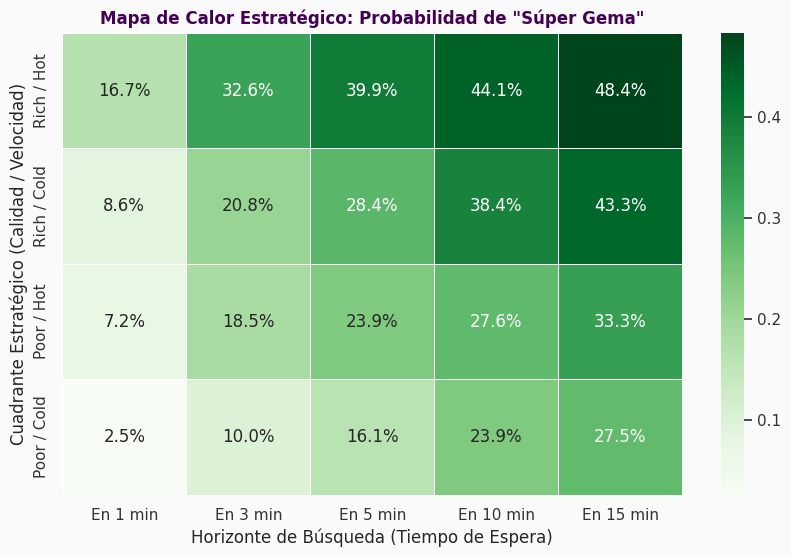

In [11]:
# ==============================================================================
# CELL 3 (v2.1): EL ORÁCULO DE LA OPORTUNIDAD (MATRIZ 2x2 Y MANIFIESTO)
# ==============================================================================
# Purpose: Calcular y visualizar la Matriz de Probabilidad de Súper Gema para
#          los cuatro cuadrantes estratégicos, con un horizonte extendido.
# ==============================================================================

from IPython.display import display, Markdown

# --- MANIFIESTO METODOLÓGICO ---

markdown_explanation = """
# **INVESTIGACIÓN 2: EL ORÁCULO DE LA OPORTUNIDAD (LA MATRIZ DE PROBABILIDAD)**

Esta investigación refina el análisis de probabilidad, reconociendo que la **velocidad** del mercado y la **calidad** del mercado son dos dimensiones ortogonales de la "Suerte". Para tomar una decisión informada, debemos entender la probabilidad de éxito en cada uno de los cuatro **Cuadrantes Estratégicos** que emergen de su interacción.

---

### **Metodología: La Matriz de Transición de Estados**

Construimos una Matriz de Probabilidad que responde a la pregunta: *"Dado el estado actual del mercado, ¿cuál es la probabilidad de que una 'Súper Gema' aparezca en un horizonte de tiempo futuro $\\Delta t$?"*

**1. Definición de los Cuadrantes Estratégicos:**
Cada oferta se clasifica en uno de cuatro estados, basados en dos ejes:
- **Eje de Velocidad (`Fast`/`Slow`):** Determinado por un modelo de clustering (`GMM`) sobre el `time_since_last_offer`.
- **Eje de Calidad (`Rich`/`Poor`):** Determinado por si el `Market Quality Index` de la sesión es mayor o menor a `1.0`.

**2. El Cálculo de la Probabilidad Condicional:**
Para cada oferta $O_t$ en el tiempo $t$ y clasificada en un Cuadrante $C$, y para cada horizonte de tiempo $\\Delta t$, se realiza una "auditoría de futuro" para verificar si existe al menos una "Súper Gema" ($IQ \\ge 1.5$) en el intervalo $(t, t + \\Delta t]$.

La probabilidad se calcula como la frecuencia de éxito, condicionada por el cuadrante de la oferta original:

$$ P(\\text{Súper Gema en } \\Delta t \\, | \\, \\text{Cuadrante}_t = C) = \\frac{\\sum \\mathbb{I}(\\text{Éxito})}{\\text{Total de Búsquedas en } C} $$

Donde $\\mathbb{I}(\\cdot)$ es la función indicadora.

**El resultado es el "Mapa de Calor Estratégico":** una herramienta de `war-gaming` que cuantifica la recompensa de la paciencia en cada posible estado del campo de batalla.
"""

display(Markdown(markdown_explanation))


if 'df_opportunity_cost' in locals() and not df_opportunity_cost.empty:

    print("\n--- CALCULANDO PROBABILIDADES PARA LA MATRIZ 2x2 (HORIZONTE EXTENDIDO) ---")

    # 1. DEFINICIÓN DEL EJE DE CALIDAD (Rich vs. Poor)
    mqi_per_session = df_opportunity_cost.groupby('session_fk')['offer_quality_index'].mean().to_dict()
    df_opportunity_cost['session_mqi'] = df_opportunity_cost['session_fk'].map(mqi_per_session)
    df_opportunity_cost['quality_state'] = df_opportunity_cost['session_mqi'].apply(
        lambda x: 'Rich' if x >= 1.0 else 'Poor'
    )

    # 2. CREACIÓN DEL CUADRANTE ESTRATÉGICO
    df_opportunity_cost['quadrant'] = df_opportunity_cost['quality_state'] + ' / ' + df_opportunity_cost['market_state']

    print("✅ Cuadrantes Estratégicos Asignados.")

    # --- 3. CÁLCULO DE PROBABILIDAD POR CUADRANTE (HORIZONTE EXTENDIDO) ---
    print("\n⏳ Auditando futuros posibles por cuadrante...")
    df_prob = df_opportunity_cost.sort_values('offer_timestamp').copy()

    # HORIZONTE EXTENDIDO
    time_windows_sec = [60, 180, 300, 600, 900] # 1, 3, 5, 10, 15 minutos

    results = []
    # (El bucle de cálculo es el mismo)
    for index, row in df_prob.iterrows():
        current_time = row['offer_timestamp']
        for window in time_windows_sec:
            future_offers = df_prob[
                (df_prob['offer_timestamp'] > current_time) &
                (df_prob['offer_timestamp'] <= current_time + pd.Timedelta(seconds=window))
            ]
            found_super_gem = future_offers['is_super_gem'].any()
            results.append({
                'quadrant': row['quadrant'],
                'time_window_sec': window,
                'found_super_gem': found_super_gem
            })

    prob_df = pd.DataFrame(results)

    # 4. AGREGACIÓN Y PRESENTACIÓN DE LA MATRIZ
    final_prob_matrix = prob_df.groupby(['quadrant', 'time_window_sec'])['found_super_gem'].mean().unstack()
    final_prob_matrix.columns = ['En 1 min', 'En 3 min', 'En 5 min', 'En 10 min', 'En 15 min']

    quadrant_order = ['Rich / Hot', 'Rich / Cold', 'Poor / Hot', 'Poor / Cold']
    final_prob_matrix = final_prob_matrix.reindex(quadrant_order)

    print("\n## 🎲 Matriz de Probabilidad de Súper Gema por Cuadrante Estratégico")
    display(final_prob_matrix.style.format('{:.1%}')
                             .set_caption("La probabilidad de éxito al esperar, desglosada por la realidad del mercado.")
                             .background_gradient(cmap='Greens'))

    # --- 5. VISUALIZACIÓN DEL MAPA DE CALOR ESTRATÉGICO ---

    plt.figure(figsize=(10, 6))
    sns.heatmap(final_prob_matrix, annot=True, fmt=".1%", cmap="Greens", linewidths=.5)

    plt.title('Mapa de Calor Estratégico: Probabilidad de "Súper Gema"', color=OPUS_PURPLE)
    plt.xlabel('Horizonte de Búsqueda (Tiempo de Espera)')
    plt.ylabel('Cuadrante Estratégico (Calidad / Velocidad)')
    plt.show()

else:
    print("🔴 No se puede ejecutar la Investigación 2. El DataFrame `df_opportunity_cost` no está cargado.")

--- 🎲 SIMULADOR DE ESTRATEGIAS ---
Calculando escenarios para un Umbral de Decisión de: $180/hr...

## 🎲 Matriz de Probabilidad de Éxito (Encontrar > $180/hr)


,En 1 min,En 3 min,En 5 min,En 10 min,En 15 min
quadrant,,,,,
Rich / Hot,81.0%,89.4%,91.0%,92.6%,93.2%
Rich / Cold,56.1%,78.9%,85.9%,89.8%,91.8%
Poor / Hot,62.0%,83.6%,88.6%,90.5%,91.1%
Poor / Cold,43.8%,71.1%,79.1%,87.9%,89.5%



## ♟️ Matriz de Decisión: VEN de esperar por una oferta > $180/hr


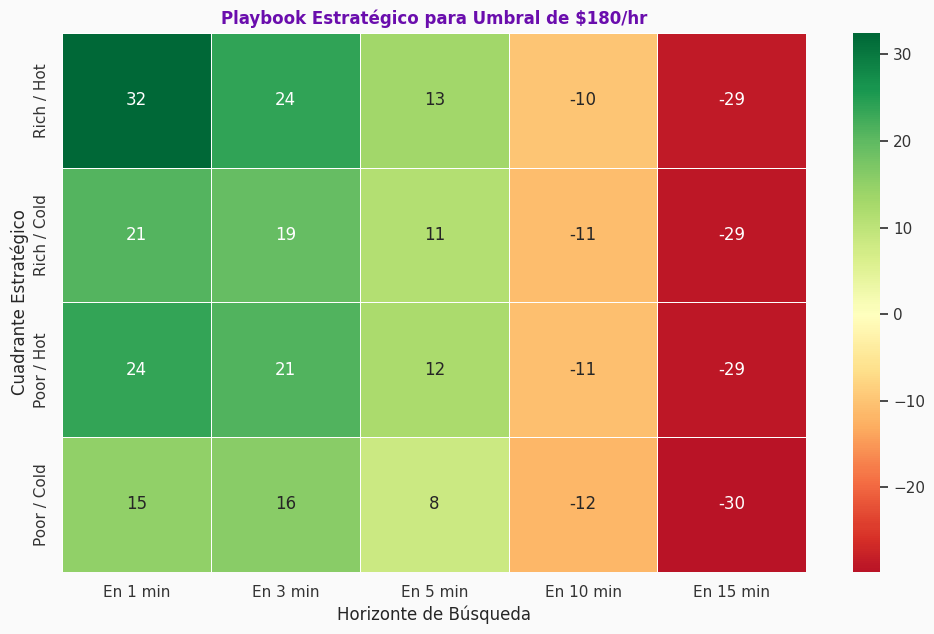

Ingresa tu Umbral de EPH (ej. 200) o escribe 'salir' para terminar: salir
--- Simulación Terminada ---


In [16]:
# ==============================================================================
# CELL 3 (v3.2): EL SIMULADOR DE ESTRATEGIAS (CON VALOR ESPERADO)
# ==============================================================================
# Purpose: Ejecutar el análisis de VEN usando el Valor Esperado de las ofertas
#          exitosas como el premio de la búsqueda.
# Fixes:   Reemplazado 'quadrants' por 'quadrant_order'.
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown, clear_output

# Colores y estilos (si no están definidos previamente)
OPUS_PURPLE = "#6a0dad"

if 'df_opportunity_cost' in locals() and not df_opportunity_cost.empty:

    # --- 1. FUNCIÓN MAESTRA DE SIMULACIÓN Y VISUALIZACIÓN ---

    def simulate_strategy(umbral_eph):

        clear_output(wait=True)
        print("--- 🎲 SIMULADOR DE ESTRATEGIAS ---")
        print(f"Calculando escenarios para un Umbral de Decisión de: ${umbral_eph}/hr...")

        # --- 1.1. INVESTIGACIÓN 1: El Costo y el Premio ---

        # Arquetipo de la Oferta Base (la que rechazas) - Promedio local
        props_base = df_opportunity_cost[df_opportunity_cost['eph_real'].between(umbral_eph - 10, umbral_eph + 10)][['upfront_fare', 'est_trip_time_sec', 'time_to_pickup_sec']].median()

        # Arquetipo de la Oferta Objetivo (EL PREMIO ESPERADO)
        # Calculamos el promedio de las propiedades de TODAS las ofertas por encima del umbral
        df_objetivo = df_opportunity_cost[df_opportunity_cost['eph_real'] >= umbral_eph]

        if len(df_objetivo) < 5: # Validación de estadística mínima
            print(f"\n⚠️ No hay suficientes datos para ofertas > ${umbral_eph}. Intenta con un umbral más bajo.")
            return

        props_objetivo = df_objetivo[['upfront_fare', 'est_trip_time_sec', 'time_to_pickup_sec']].median()

        if props_base.isnull().any() or props_objetivo.isnull().any():
            print(f"\n⚠️ No hay suficientes datos para los arquetipos alrededor de ${umbral_eph}. Intenta con otro valor.")
            return

        # --- 1.2. INVESTIGACIÓN 2: La Probabilidad ---
        df_sim = df_opportunity_cost.copy()
        df_sim['is_above_threshold'] = (df_sim['eph_real'] >= umbral_eph).astype(int)

        time_windows_sec = [60, 180, 300, 600, 900]
        prob_results = []

        # Ordenar por tiempo para simulación correcta
        df_prob = df_sim.sort_values('offer_timestamp')

        for index, row in df_prob.iterrows():
            current_time = row['offer_timestamp']
            # Usar .get() para evitar error si la columna quadrant no existe o es nula
            current_quadrant = row.get('quadrant', 'Unknown')

            for window in time_windows_sec:
                future_offers = df_prob[(df_prob['offer_timestamp'] > current_time) & (df_prob['offer_timestamp'] <= current_time + pd.Timedelta(seconds=window))]
                found_better = future_offers['is_above_threshold'].any()
                prob_results.append({'quadrant': current_quadrant, 'time_window_sec': window, 'found_better': found_better})

        prob_df = pd.DataFrame(prob_results)

        # Calcular media de éxito por cuadrante y ventana
        prob_matrix = prob_df.groupby(['quadrant', 'time_window_sec'])['found_better'].mean().unstack()
        prob_matrix.columns = [f'En {int(c/60)} min' for c in prob_matrix.columns]

        # Definir el orden deseado
        quadrant_order = ['Rich / Hot', 'Rich / Cold', 'Poor / Hot', 'Poor / Cold']

        # Filtrar solo los cuadrantes que existen en los datos para evitar error de reindex
        available_quadrants = [q for q in quadrant_order if q in prob_matrix.index]
        prob_matrix = prob_matrix.reindex(available_quadrants)

        # --- 1.3. INVESTIGACIÓN 3: La Síntesis (Valor Esperado Neto) ---
        ven_results = []

        # EPH Base Constante (Lo que ganas si aceptas la oferta mediocre ahora)
        eph_base_constante = (props_base['upfront_fare'] / (props_base['time_to_pickup_sec'] + props_base['est_trip_time_sec'])) * 3600

        for quadrant in available_quadrants:
            for i, window_sec in enumerate(time_windows_sec):
                # Obtener probabilidad de la matriz calculada
                prob_mejor = prob_matrix.loc[quadrant].iloc[i]

                # Calcular EPH del escenario Éxito (encuentras una mejor) + Costo de espera (window_sec)
                total_cycle_objetivo = window_sec + props_objetivo['time_to_pickup_sec'] + props_objetivo['est_trip_time_sec']
                eph_objetivo_decayed = (props_objetivo['upfront_fare'] / total_cycle_objetivo) * 3600 if total_cycle_objetivo > 0 else 0

                # Calcular EPH del escenario Fracaso (te rindes y aceptas una base) + Costo de espera (window_sec)
                total_cycle_base_decayed = window_sec + props_base['time_to_pickup_sec'] + props_base['est_trip_time_sec']
                eph_base_decayed = (props_base['upfront_fare'] / total_cycle_base_decayed) * 3600 if total_cycle_base_decayed > 0 else 0

                # Valor Esperado Ponderado
                ev_esperar = (prob_mejor * eph_objetivo_decayed) + ((1 - prob_mejor) * eph_base_decayed)

                # Valor Esperado NETO (Comparado contra aceptar ahora)
                ven = ev_esperar - eph_base_constante
                ven_results.append({'quadrant': quadrant, 'time_window_sec': window_sec, 'ven_mxn_per_hour': ven})

        ven_df = pd.DataFrame(ven_results)
        ven_matrix = ven_df.pivot(index='quadrant', columns='time_window_sec', values='ven_mxn_per_hour')
        ven_matrix.columns = prob_matrix.columns

        # --- CORRECCIÓN AQUI: Usar quadrant_order (o available_quadrants) en lugar de 'quadrants' ---
        ven_matrix = ven_matrix.reindex(available_quadrants)

        # --- VISUALIZACIÓN ---
        print(f"\n## 🎲 Matriz de Probabilidad de Éxito (Encontrar > ${umbral_eph}/hr)")
        display(prob_matrix.style.format('{:.1%}').background_gradient(cmap='Greens'))

        print(f"\n## ♟️ Matriz de Decisión: VEN de esperar por una oferta > ${umbral_eph}/hr")
        plt.figure(figsize=(12, 7))
        # Ajustar centro del mapa de calor a 0 para ver ganancia (verde) vs perdida (rojo)
        sns.heatmap(ven_matrix, annot=True, fmt=".0f", cmap="RdYlGn", linewidths=.5, center=0)
        plt.title(f'Playbook Estratégico para Umbral de ${umbral_eph}/hr', color=OPUS_PURPLE)
        plt.xlabel('Horizonte de Búsqueda')
        plt.ylabel('Cuadrante Estratégico')
        plt.show()

    # --- 2. BUCLE INTERACTIVO ---
    while True:
        try:
            user_input = input("Ingresa tu Umbral de EPH (ej. 200) o escribe 'salir' para terminar: ")
            if user_input.lower() in ['salir', 'exit', 'quit']:
                print("--- Simulación Terminada ---")
                break
            umbral = int(user_input)
            # Amplié un poco el rango para pruebas
            if 50 <= umbral <= 1000:
                simulate_strategy(umbral)
            else:
                print("❌ Valor fuera de rango sugerido (50-1000).")
        except ValueError:
            print("❌ Entrada inválida. Por favor ingresa un número entero.")
        except Exception as e:
            print(f"🔴 Ocurrió un error inesperado: {e}")
            # Imprimir el traceback para facilitar debug futuro
            import traceback
            traceback.print_exc()
            break

else:
    print("🔴 No se puede ejecutar el simulador. El DataFrame `df_opportunity_cost` no está cargado o está vacío.")

In [13]:
# ==============================================================================
# CELL 3.1: CAMPAÑA DE ELASTICIDAD - LA CURVA DE OFERTA DEL AGENTE
# ==============================================================================
# Purpose: Medir la Elasticidad de la Oferta del Agente, cuantificando cómo
#          cambia la tasa de aceptación en respuesta a cambios en la calidad de la oferta.
# ==============================================================================

if 'df_opportunity_cost' in locals() and not df_opportunity_cost.empty:

    print("--- 1. PREPARACIÓN PARA ANÁLISIS DE ELASTICIDAD ---")

    # 1.1. ASEGURAR COLUMNAS NECESARIAS
    df_elasticity = df_opportunity_cost[['offer_quality_index', 'is_success']].copy().dropna()

    # 1.2. CREAR "CUBETAS DE PRECIOS" (DECILES DE CALIDAD)
    # Usamos qcut para crear 10 grupos con el mismo número de ofertas en cada uno
    df_elasticity['quality_bin'] = pd.qcut(df_elasticity['offer_quality_index'], 10, labels=False, duplicates='drop')

    print("✅ Ofertas segmentadas en 10 deciles de calidad.")

    # 1.3. CALCULAR LA CURVA DE OFERTA (RESPUESTA POR CUBETA)
    supply_curve = df_elasticity.groupby('quality_bin').agg(
        avg_quality_index=('offer_quality_index', 'mean'), # Precio Promedio (P)
        acceptance_rate=('is_success', 'mean')           # Cantidad Promedio (Q)
    ).reset_index()

    # 1.4. CALCULAR LA ELASTICIDAD
    # Usamos pct_change() para calcular (Q2-Q1)/Q1 y (P2-P1)/P1
    supply_curve['elasticity'] = supply_curve['acceptance_rate'].pct_change() / supply_curve['avg_quality_index'].pct_change()

    print("\n## 📈 Curva de Oferta del Agente (Calidad vs. Aceptación)")
    display(supply_curve.style.format({
        'avg_quality_index': '{:.3f}',
        'acceptance_rate': '{:.2%}',
        'elasticity': '{:.2f}'
    }))

    # 1.5. VISUALIZACIÓN DE LA ELASTICIDAD

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x='quality_bin', y='elasticity', data=supply_curve, palette='viridis')

    ax.axhline(1, color='r', linestyle='--', label='Elasticidad Unitaria (1.0)')

    plt.title('Elasticidad de la Oferta del Agente por Decil de Calidad', color=OPUS_PURPLE)
    plt.xlabel('Decil de Calidad de la Oferta (0 = Peor 10%, 9 = Mejor 10%)')
    plt.ylabel('Coeficiente de Elasticidad')
    plt.legend()
    plt.show()

else:
    print("🔴 No se puede ejecutar la campaña. El DataFrame `df_opportunity_cost` no está cargado.")

--- 1. PREPARACIÓN PARA ANÁLISIS DE ELASTICIDAD ---


KeyError: "['is_success'] not in index"